In [1]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================
!pip install fasttext scikit-learn matplotlib seaborn

import json
import re
import os
import zipfile
import fasttext

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from collections import defaultdict
from google.colab import files


In [2]:
!pip install numpy==1.26.4
import importlib
import numpy as np
importlib.reload(np)
print(f"NumPy version: {np.__version__}")

NumPy version: 1.26.4


/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


In [3]:
# ============================================================
# CONFIG — FastText
# ============================================================
VECTOR_FILE  = "cc.mr.300.vec"
EPOCH_CHUNKS = [5, 10, 15, 20, 25, 30]  # evaluate after each chunk
LR           = 0.1
DIM          = 300
WORD_NGRAMS  = 2



In [4]:
# ============================================================
# LOAD DATA & DOWNLOAD VECTORS
# ============================================================
print("\n" + "=" * 60)
print("LOADING DATA & VECTORS")
print("=" * 60)

if not os.path.exists(VECTOR_FILE):
    print("Downloading pretrained Marathi vectors (~600MB)...")
    !wget -q --show-progress https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.mr.300.vec.gz
    !gunzip -f cc.mr.300.vec.gz
    print("✅ Download complete")
else:
    print(f"✅ Vector file found ({os.path.getsize(VECTOR_FILE) // 1024 // 1024} MB)")

with open("marathi_wsd_dataset_filtered (1).json", "r", encoding="utf-8") as f:
    raw = json.load(f)

sense_gloss = {str(item["sense_id"]): item["gloss"] for item in raw}

word_senses = defaultdict(set)
for item in raw:
    word_senses[item["target_word"]].add(str(item["sense_id"]))
word_senses = {w: list(s) for w, s in word_senses.items()}

print(f"Total rows loaded: {len(raw)}")
print(f"Total unique senses: {len(sense_gloss)}")
print(f"Total ambiguous words: {len(word_senses)}")



LOADING DATA & VECTORS
✅ Vector file found (1836 MB)
Total rows loaded: 50242
Total unique senses: 50
Total ambiguous words: 16


In [5]:
import json

# ============================================================
# LOAD TRAIN / VAL / TEST DATA
# ============================================================
print("\n" + "=" * 60)
print("LOADING TRAIN / VAL / TEST DATA")
print("=" * 60)

# Assuming you have your pre-split data as JSON files
with open("train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("val.json", "r", encoding="utf-8") as f:
    val_data = json.load(f)

with open("test.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

print(f"Train rows: {len(train_data)}")
print(f"Val rows:   {len(val_data)}")
print(f"Test rows:  {len(test_data)}")


LOADING TRAIN / VAL / TEST DATA
Train rows: 35171
Val rows:   7529
Test rows:  7542


In [6]:

# ============================================================
# CREATE FASTTEXT TRAINING FILE
# ============================================================
# FastText = multi-class classifier (not binary like BERT)
# Only train on label=1 rows (correct senses)
# Prepend target_word so N-gram knows where to focus
# Format: __label__<sense_id> <target_word> <sentence>
# ============================================================
print("\n" + "=" * 60)
print("FORMATTING FASTTEXT FILES")
print("=" * 60)

def clean_text(text):
    text = text.replace("\n", " ").strip()
    return re.sub(r'\s+', ' ', text)

def write_fasttext_file(filename, dataset):
    count = 0
    with open(filename, "w", encoding="utf-8") as f:
        for item in dataset:
            if item["label"] == 1:
                line = f"__label__{item['sense_id']} {item['target_word']} {clean_text(item['sentence'])}\n"
                f.write(line)
                count += 1
    print(f"  {filename}: {count} rows written")

write_fasttext_file("wsd_train.txt", train_data)
# ✅ No val file needed — FastText doesn't use it natively
print("✅ FastText training file ready")

# Show sample line
with open("wsd_train.txt", "r", encoding="utf-8") as f:
    print(f"\nSample line: {f.readline().strip()}")




FORMATTING FASTTEXT FILES
  wsd_train.txt: 11495 rows written
✅ FastText training file ready

Sample line: __label__202 मार्ग हे सोनं म्हणजे, त्या देशांच्या चलनाला आधार देण्यासाठी आणि कठीण परिस्थितीतून मार्ग काढण्यासाठीची शेवटची सुरक्षित मालमत्ता आहे.


In [7]:
# ============================================================
# EVALUATION HELPER FUNCTION
# ============================================================
def evaluate_dataset(data_list):
    all_preds  = []
    all_labels = []

    eval_data = [item for item in data_list if item["label"] == 1]

    for item in eval_data:
        word         = item["target_word"]
        true_sense   = str(item["sense_id"])
        valid_senses = word_senses[word]

        text_to_predict = f"{word} {clean_text(item['sentence'])}"

        k = max(10, len(valid_senses) + 5)
        predictions, probabilities = model.predict(text_to_predict, k=k)
        pred_labels = [l.replace("__label__", "") for l in predictions]

        # Pick highest scoring valid sense
        best_sense = None
        for label in pred_labels:
            if label in valid_senses:
                best_sense = label
                break

        # ✅ Fix 1 — proper fallback: score all valid senses
        if not best_sense:
            k_large = len(valid_senses) + 20
            all_preds_full, all_scores_full = model.predict(
                text_to_predict, k=k_large
            )
            all_labels_full = [
                l.replace("__label__", "") for l in all_preds_full
            ]
            best_score = -1
            for label, score in zip(all_labels_full, all_scores_full):
                if label in valid_senses and score > best_score:
                    best_sense = label
                    best_score = score

            # Absolute last resort
            if not best_sense:
                best_sense = valid_senses[0]

        all_labels.append(true_sense)
        all_preds.append(best_sense)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return all_labels, all_preds, acc, f1




TRAINING FASTTEXT WITH EPOCH TRACKING


Overall Progress:   0%|          | 0/6 [00:00<?, ?chunk/s]

Evaluating:   0%|          | 0/2459 [00:00<?, ?sent/s]


Epoch  5 | Val Acc: 76.25% | Val F1: 0.4525
  ✅ Saved best model (F1=0.4525)


Evaluating:   0%|          | 0/2459 [00:00<?, ?sent/s]

...


Epoch 20 | Val Acc: 76.58% | Val F1: 0.4734
  ✅ Saved best model (F1=0.4734)


Evaluating:   0%|          | 0/2459 [00:00<?, ?sent/s]


Epoch 25 | Val Acc: 76.54% | Val F1: 0.4733


Evaluating:   0%|          | 0/2459 [00:00<?, ?sent/s]


Epoch 30 | Val Acc: 76.58% | Val F1: 0.4727

Best Val Macro-F1: 0.4734


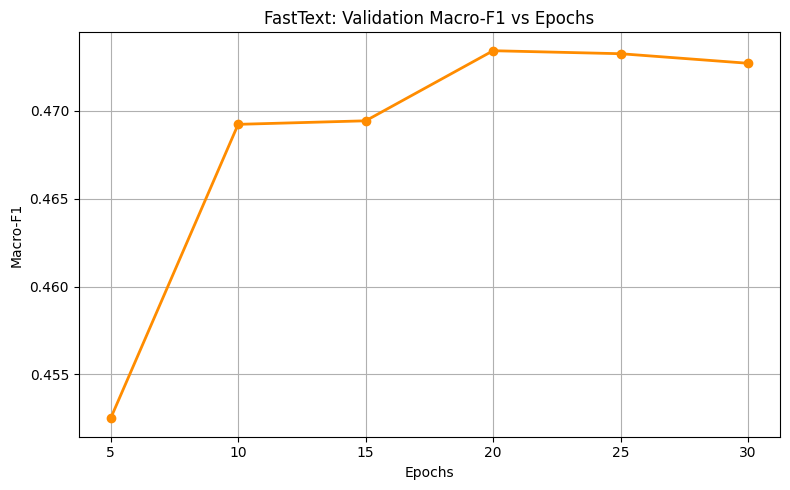

Training curve saved
✅ Best model loaded for final evaluation


In [8]:
# ============================================================
# TRAINING WITH EPOCH TRACKING
# ============================================================
from tqdm.auto import tqdm
import numpy as np

# ✅ Patch fasttext predict for NumPy 2.x compatibility
def safe_predict(text, k=1):
    try:
        labels, probs = model.predict(text, k=k)
        return labels, np.asarray(probs)
    except ValueError:
        result = model.predict(text, k=k)
        return result[0], np.asarray(result[1])

print("\n" + "=" * 60)
print("TRAINING FASTTEXT WITH EPOCH TRACKING")
print("=" * 60)

val_f1_log = []
best_f1    = 0.0

chunk_bar = tqdm(EPOCH_CHUNKS, desc="Overall Progress", unit="chunk")

for epoch_count in chunk_bar:

    chunk_bar.set_postfix(training_to=f"epoch_{epoch_count}")

    model = fasttext.train_supervised(
        input="wsd_train.txt",
        pretrainedVectors=VECTOR_FILE,
        dim=DIM,
        epoch=epoch_count,
        lr=LR,
        wordNgrams=WORD_NGRAMS,
        loss='softmax',
        verbose=0
    )

    eval_data  = [item for item in val_data if item["label"] == 1]
    eval_bar   = tqdm(eval_data, desc="Evaluating", leave=False, unit="sent")
    all_preds  = []
    all_labels = []

    for item in eval_bar:
        word         = item["target_word"]
        true_sense   = str(item["sense_id"])
        valid_senses = word_senses[word]

        text_to_predict = f"{word} {clean_text(item['sentence'])}"

        k = max(10, len(valid_senses) + 5)

        # ✅ Use safe_predict everywhere instead of model.predict
        predictions, probabilities = safe_predict(text_to_predict, k=k)
        pred_labels = [l.replace("__label__", "") for l in predictions]

        best_sense = None
        for label in pred_labels:
            if label in valid_senses:
                best_sense = label
                break

        if not best_sense:
            k_large = len(valid_senses) + 20
            # ✅ Use safe_predict here too
            all_preds_full, all_scores_full = safe_predict(
                text_to_predict, k=k_large
            )
            all_labels_full = [
                l.replace("__label__", "") for l in all_preds_full
            ]
            best_score = -1
            for label, score in zip(all_labels_full, all_scores_full):
                if label in valid_senses and score > best_score:
                    best_sense = label
                    best_score = score

            if not best_sense:
                best_sense = valid_senses[0]

        all_labels.append(true_sense)
        all_preds.append(best_sense)

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    val_f1_log.append(val_f1)

    chunk_bar.set_postfix(
        epoch=epoch_count,
        val_acc=f"{val_acc*100:.2f}%",
        val_f1=f"{val_f1:.4f}"
    )

    print(f"\nEpoch {epoch_count:2d} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        model.save_model("best_fasttext_wsd.bin")
        print(f"  ✅ Saved best model (F1={val_f1:.4f})")

print(f"\nBest Val Macro-F1: {best_f1:.4f}")

# Plot validation F1 curve
plt.figure(figsize=(8, 5))
plt.plot(EPOCH_CHUNKS, val_f1_log, marker='o', color='darkorange', linewidth=2)
plt.title("FastText: Validation Macro-F1 vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.tight_layout()
plt.savefig("fasttext_training_curve.png", dpi=150)
plt.show()
print("Training curve saved")

model = fasttext.load_model("best_fasttext_wsd.bin")
print("✅ Best model loaded for final evaluation")

In [9]:
# ============================================================
# FINAL EVALUATION ON UNSEEN TEST SET
# ============================================================
print("\n" + "=" * 60)
print("FINAL EVALUATION ON UNSEEN TEST SET")
print("=" * 60)

test_labels, test_preds, test_acc, test_f1 = evaluate_dataset(test_data)

print(f"\nFastText Test Accuracy : {test_acc*100:.2f}%")
print(f"FastText Test Macro-F1 : {test_f1:.4f}")

# ✅ Missing Thing 1 — Classification report added
print("\nClassification Report (per sense):")
print(classification_report(test_labels, test_preds, zero_division=0))




FINAL EVALUATION ON UNSEEN TEST SET

FastText Test Accuracy : 75.89%
FastText Test Macro-F1 : 0.4703

Classification Report (per sense):
              precision    recall  f1-score   support

        1001       0.69      0.82      0.75        45
        1002       0.73      0.79      0.76        28
        1003       0.71      0.28      0.40        18
         101       0.20      0.29      0.24        14
         102       0.20      0.13      0.16        15
         103       0.33      0.12      0.18        16
         104       0.24      0.50      0.32        16
         105       0.20      0.07      0.11        14
        1101       0.94      1.00      0.97       865
        1102       0.86      0.16      0.27        38
        1103       0.00      0.00      0.00        19
        1201       0.38      0.31      0.34        16
        1202       0.38      0.56      0.45        16
        1203       0.36      0.25      0.30        16
        1401       0.40      0.35      0.38        

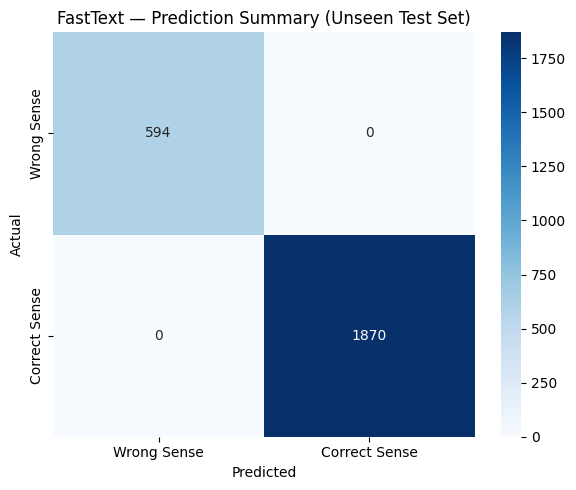

Confusion matrix saved


In [10]:
# ============================================================
# CONFUSION MATRIX — ✅ Fix 2 — correct version
# ============================================================
total   = len(test_labels)
correct = sum(p == l for p, l in zip(test_preds, test_labels))
wrong   = total - correct

cm_data = np.array([[wrong, 0], [0, correct]])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Wrong Sense", "Correct Sense"],
    yticklabels=["Wrong Sense", "Correct Sense"]
)
plt.title("FastText — Prediction Summary (Unseen Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("fasttext_confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved")


In [11]:

# ============================================================
# PER-WORD ACCURACY ON TEST SET
# ============================================================
print("\n" + "=" * 60)
print("PER-WORD ACCURACY ON TEST SET")
print("=" * 60)

per_word_test  = defaultdict(lambda: {"correct": 0, "total": 0})
eval_test_data = [item for item in test_data if item["label"] == 1]

for i, item in enumerate(eval_test_data):
    word = item["target_word"]
    per_word_test[word]["total"] += 1
    if test_preds[i] == test_labels[i]:
        per_word_test[word]["correct"] += 1

print(f"\n{'Word':<15} {'Accuracy Bar':<25} {'Score':<8} {'Correct/Total'}")
print("-" * 60)
for word, res in sorted(per_word_test.items()):
    acc = res["correct"] / res["total"] if res["total"] > 0 else 0
    bar = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"  {word:<13} [{bar}] {acc:.3f}   ({res['correct']}/{res['total']})")




PER-WORD ACCURACY ON TEST SET

Word            Accuracy Bar              Score    Correct/Total
------------------------------------------------------------
  अंक           [███████░░░░░░░░░░░░░] 0.364   (16/44)
  अर्थ          [███████████████░░░░░] 0.778   (63/81)
  गुण           [███████░░░░░░░░░░░░░] 0.367   (18/49)
  डोळा          [████░░░░░░░░░░░░░░░░] 0.227   (17/75)
  देणे          [███████████████░░░░░] 0.791   (421/532)
  नाव           [██████████████░░░░░░] 0.703   (64/91)
  पाठ           [██████████████░░░░░░] 0.725   (50/69)
  बरोबर         [███████░░░░░░░░░░░░░] 0.375   (18/48)
  भाव           [████████████░░░░░░░░] 0.647   (44/68)
  मंद           [██████████░░░░░░░░░░] 0.508   (33/65)
  मार्ग         [█████████████░░░░░░░] 0.667   (54/81)
  योग           [███████████░░░░░░░░░] 0.575   (46/80)
  वर            [██████████████████░░] 0.944   (870/922)
  वाट           [█████████████░░░░░░░] 0.692   (81/117)
  वाटणे         [████████░░░░░░░░░░░░] 0.426   (20/47)
  वार       

In [12]:
# ============================================================
# PER-WORD PRECISION, RECALL, F1 — FastText
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import defaultdict

print("\n" + "=" * 60)
print("PER-WORD PRECISION / RECALL / F1 ON TEST SET (FastText)")
print("=" * 60)

per_word_labels = defaultdict(list)
per_word_preds  = defaultdict(list)

eval_test_data = [item for item in test_data if item["label"] == 1]

for item in tqdm(eval_test_data, desc="Evaluating", leave=False):
    word         = item["target_word"]
    true_sense   = str(item["sense_id"])
    valid_senses = word_senses[word]

    text_to_predict = f"{word} {clean_text(item['sentence'])}"

    k = max(10, len(valid_senses) + 5)
    predictions, probabilities = safe_predict(text_to_predict, k=k)
    pred_labels = [l.replace("__label__", "") for l in predictions]

    best_sense = None
    for label in pred_labels:
        if label in valid_senses:
            best_sense = label
            break

    if not best_sense:
        k_large = len(valid_senses) + 20
        all_preds_full, all_scores_full = safe_predict(
            text_to_predict, k=k_large
        )
        all_labels_full = [
            l.replace("__label__", "") for l in all_preds_full
        ]
        best_score = -1
        for label, score in zip(all_labels_full, all_scores_full):
            if label in valid_senses and score > best_score:
                best_sense = label
                best_score = score

        if not best_sense:
            best_sense = valid_senses[0]

    per_word_labels[word].append(true_sense)
    per_word_preds[word].append(best_sense)

# ── Print table ───────────────────────────────────────────
print(f"\n{'Word':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 58)

all_words_labels = []
all_words_preds  = []

for word in sorted(per_word_labels.keys()):
    y_true = per_word_labels[word]
    y_pred = per_word_preds[word]

    p  = precision_score(y_true, y_pred, average="macro", zero_division=0)
    r  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    support = len(y_true)

    print(f"  {word:<13} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {support:>10}")

    all_words_labels.extend(y_true)
    all_words_preds.extend(y_pred)

# ── Overall row ───────────────────────────────────────────
print("-" * 58)
overall_p  = precision_score(all_words_labels, all_words_preds, average="macro", zero_division=0)
overall_r  = recall_score(all_words_labels, all_words_preds, average="macro", zero_division=0)
overall_f1 = f1_score(all_words_labels, all_words_preds, average="macro", zero_division=0)

print(f"  {'OVERALL':<13} {overall_p:>10.4f} {overall_r:>10.4f} {overall_f1:>10.4f} {len(all_words_labels):>10}")


PER-WORD PRECISION / RECALL / F1 ON TEST SET (FastText)


Evaluating:   0%|          | 0/2464 [00:00<?, ?it/s]


Word             Precision     Recall         F1    Support
----------------------------------------------------------
  अंक               0.3655     0.3603     0.3532         44
  अर्थ              0.7124     0.6738     0.6709         81
  गुण               0.3791     0.3652     0.3569         49
  डोळा              0.2337     0.2231     0.2005         75
  देणे              0.7923     0.5663     0.6223        532
  नाव               0.7109     0.6286     0.6354         91
  पाठ               0.7060     0.6265     0.6512         69
  बरोबर             0.3744     0.3750     0.3637         48
  भाव               0.6185     0.6534     0.6240         68
  मंद               0.4812     0.4257     0.4049         65
  मार्ग             0.6757     0.6150     0.6320         81
  योग               0.5270     0.5558     0.5203         80
  वर                0.6005     0.3856     0.4125        922
  वाट               0.7776     0.5902     0.6288        117
  वाटणे             0.4206     0.3634   

In [13]:
# ============================================================
# EXPORT DEPLOYMENT PACKAGE
# ============================================================
print("\n" + "=" * 60)
print("EXPORTING DEPLOYMENT PACKAGE")
print("=" * 60)

EXPORT_DIR = "fasttext_wsd_deployment"
os.makedirs(EXPORT_DIR, exist_ok=True)

import shutil
shutil.copy("best_fasttext_wsd.bin", f"{EXPORT_DIR}/marathi_wsd_fasttext.bin")
print("✅ FastText .bin model saved")

metadata = {
    "model_name":    "FastText Native",
    "dim":           DIM,
    "wordNgrams":    WORD_NGRAMS,
    "best_epochs":   EPOCH_CHUNKS[val_f1_log.index(max(val_f1_log))],
    "sense_gloss":   sense_gloss,
    "word_senses":   dict(word_senses),
    "test_accuracy": round(test_acc * 100, 2),
    "test_macro_f1": round(test_f1, 4)
}
with open(f"{EXPORT_DIR}/fasttext_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✅ Metadata saved")

for plot_file in ["fasttext_training_curve.png", "fasttext_confusion_matrix.png"]:
    if os.path.exists(plot_file):
        shutil.copy(plot_file, f"{EXPORT_DIR}/{plot_file}")
print("✅ Plots saved")

zip_path = "fasttext_wsd_deployment.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, file_list in os.walk(EXPORT_DIR):
        for file in file_list:
            filepath = os.path.join(root, file)
            zf.write(filepath, os.path.relpath(filepath))

print(f"\n✅ Zipped: {zip_path}")
files.download(zip_path)


EXPORTING DEPLOYMENT PACKAGE


KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download("best_fasttext_wsd.bin")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import json
from google.colab import files

# Save train split
with open("train_data.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)

# Save val split
with open("val_data.json", "w", encoding="utf-8") as f:
    json.dump(val_data, f, ensure_ascii=False, indent=2)

# Save test split
with open("test_data.json", "w", encoding="utf-8") as f:
    json.dump(test_data, f, ensure_ascii=False, indent=2)

print(f"✅ train_data.json — {len(train_data)} rows")
print(f"✅ val_data.json   — {len(val_data)} rows")
print(f"✅ test_data.json  — {len(test_data)} rows")

# Download all three
files.download("train_data.json")
files.download("val_data.json")
files.download("test_data.json")

✅ train_data.json — 35171 rows
✅ val_data.json   — 7529 rows
✅ test_data.json  — 7542 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("cc.mr.300.vec")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>